In [1]:
import pandas as pd
import seaborn.objects as so
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np

plt.style.use("cppp.notebook")

theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data


## Load data

In [2]:
df = load_multisensory_data(base_path="../data")

df["tracking_error"] = df["lefty_pos"] - df["righty_pos"]

df["offset_sign"] = df.groupby("participant")["cursor_offset"].transform(lambda x: np.sign(x.mean()))

df["tracking_error"] *= df["offset_sign"]

df["time_within_trial"] = df.groupby(["participant", "trial_number"])["time"].transform(lambda x: x - x.min())

participants = df["participant"].unique()

participants_to_exclude = []
participants = [p for p in participants if p not in participants_to_exclude]

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)


## Load simulated CCGs

In [3]:
ccgs = pd.concat([pd.read_csv(f"../results/ppc/multisensory-simulations-ppc-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

ccgs["Condition"] = ccgs["condition"].map({"vis": "Vision", "prop": "Proprioception", "multi": "Multisensory"})
ccgs["Visual target"] = ccgs["vis_noise"].map({1: "Cursor", 2: "Cloud"})
ccgs["model"] = ccgs["model"].map({"data": "Data", "optimal": "Optimal integration", "no_integration": "No integration", "equal_integration": "Equal integration"})

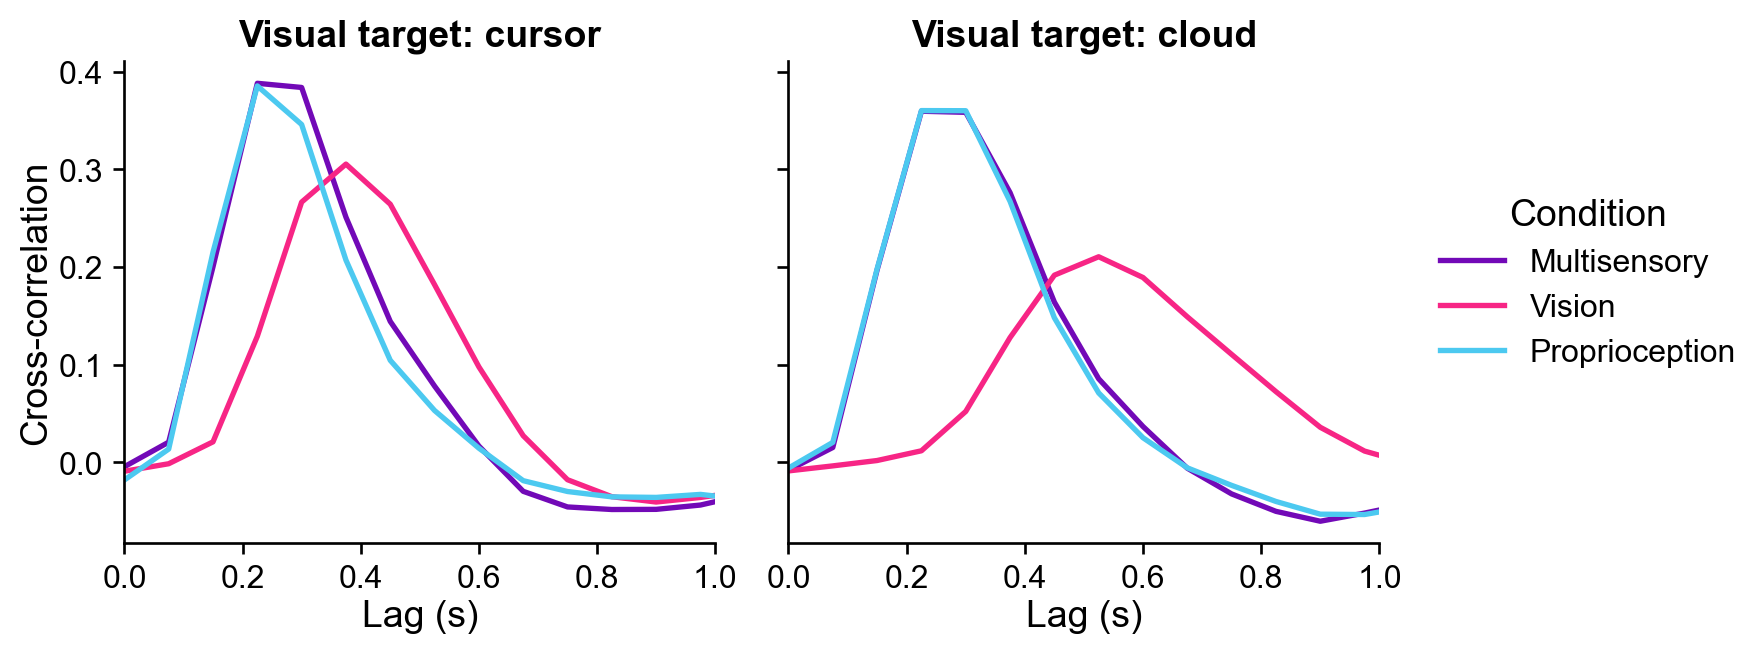

In [4]:
palette = {'Vision': "#F72585", 'Proprioception':  "#4CC9F0", 'Multisensory': "#7209B7"}
g = (so.Plot(ccgs[ccgs["model"] == "Data"], x="lag", y="correlation", color="Condition")
    .add(so.Line(), so.Agg())
    # .add(so.Band(), so.Est())
    .facet(col="vis_noise", 
    # row="model", order={"row": ["data", "optimal", "no_integration", "equal_integration"]}
           )
    .label(x="Lag (s)", y="Cross-correlation", title=lambda d: "Visual target: cloud" if d == "2" else "Visual target: cursor")
    .limit(x=(-0.0, 1.0))
    # .scale(color=so.Nominal({"vis": sns.color_palette("colorblind")[3], "prop": sns.color_palette("colorblind")[0], "multi": sns.color_palette("colorblind")[4]}))
    .scale(color=so.Nominal(palette))
    .layout(size=(7.5, 3.5))
)
g.save("../figures/multisensory_ccgs.svg", bbox_inches="tight")

In [5]:
ccg_params = ccgs.groupby(["participant", "model", "Condition", "Visual target"]).apply(
    lambda g: pd.Series({
        'peak': g['correlation'].max(),
        'lag': g.loc[g['correlation'].idxmax(), 'lag']
    }),
    include_groups=False
).reset_index()

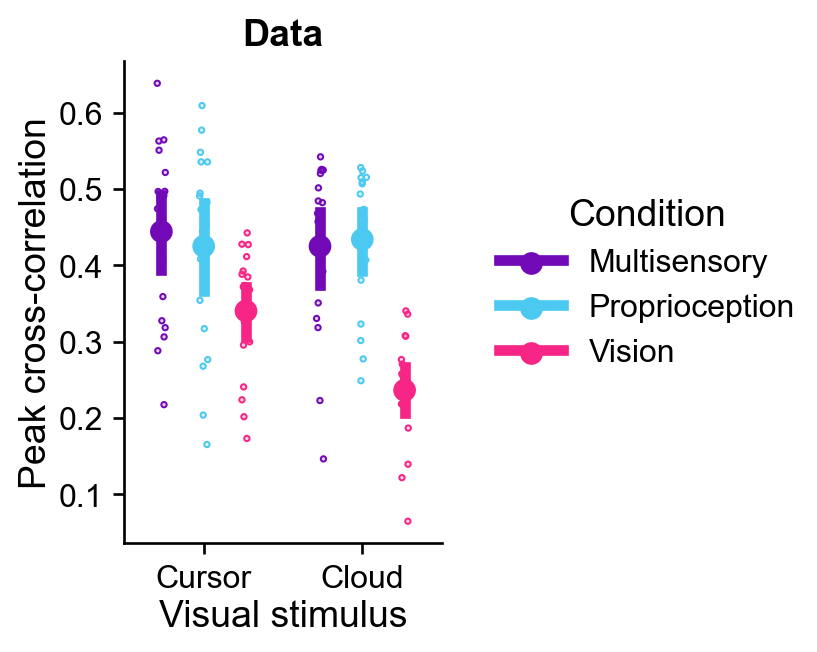

In [6]:
# [ccg_params["model"] == "data"]

g = (so.Plot(ccg_params[ccg_params["model"].isin(["Data"])], x="Visual target", y="peak", color="Condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="model")
    .scale(x=so.Nominal(order=["Cursor", "Cloud"]), color=so.Nominal(palette))
    .label(x="Visual stimulus", y="Peak cross-correlation")
    .layout(size=(2.5, 3.5))
    # .share(y=False)
)

g.save("../figures/multisensory_ccg_peaks.svg", bbox_inches="tight")

In [7]:
df["phase"].unique()

array(['pre_cal', 'calibration', 'post_cal'], dtype=object)

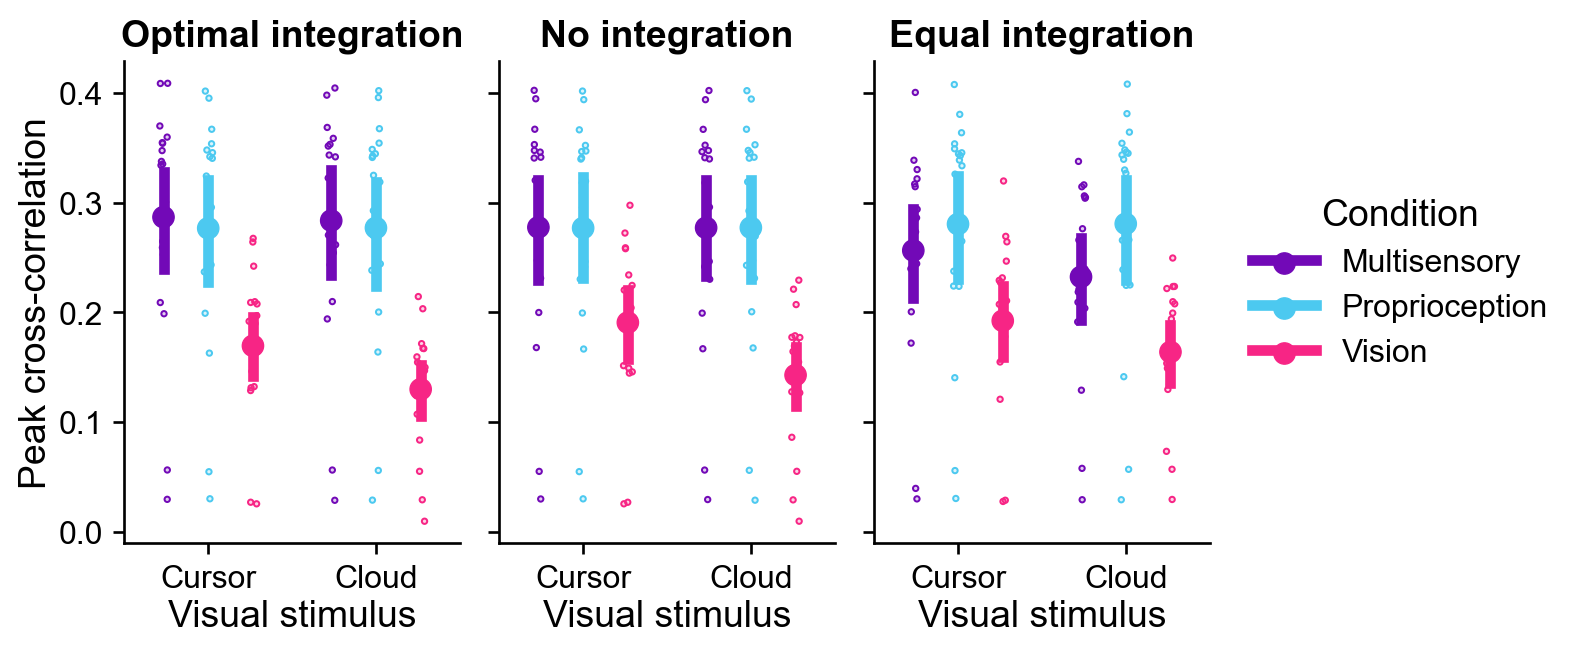

In [8]:
g = (so.Plot(ccg_params[ccg_params["model"].isin(["Optimal integration", "No integration", "Equal integration"])], x="Visual target", y="peak", color="Condition")
    .add(so.Dot(pointsize=8), so.Agg(), so.Dodge())
    .add(so.Dots(pointsize=2), so.Dodge(), so.Jitter())
    .add(so.Range(linewidth=4), so.Est(errorbar="ci"), so.Dodge())
    .facet(col="model", order=["Optimal integration", "No integration", "Equal integration"])
    .scale(x=so.Nominal(order=["Cursor", "Cloud"]), color=so.Nominal(palette))
    .label(x="Visual stimulus", y="Peak cross-correlation")
    # .share(y=False)
    .layout(size=(6.5, 3.5))
)

g.save("../figures/multisensory_ccg_peaks_models.svg", bbox_inches="tight")

## Calibration phase

In [9]:
df_sim = pd.concat([pd.read_csv(f"../results/calibration/multisensory-simulations-calibration-{p}_1_2_7453_1000_2500_4_MultisensoryDelayModelPointMassDynamics.csv") for p in participants]).reset_index(drop=True)

df_sim["tracking_error"] = df_sim["lefty_pos"] - (df_sim["righty_pos"])

df_sim["offset_sign"] = df_sim.groupby("participant")["cursor_offset"].transform(
    lambda x: np.sign(x.mean())
)

df_sim["tracking_error"] *= df_sim["offset_sign"]



In [10]:
df = df[df["time_within_trial"] > 3.0]

# replace 'value' with your measurement column name
pre_means = (
    df[df['phase'] == 'pre_cal']
    .groupby(['participant', 'type', 'vis_noise'])['tracking_error']
    .mean()
    .reset_index(name='pre_mean')
)

df = df.merge(pre_means, on=['participant', 'type', 'vis_noise'], how='left')
df['tracking_error'] = df['tracking_error'] - df['pre_mean']
# optional: handle groups with no pre_cal by filling
# df['tracking_error_centered'] = df['value'] - df['pre_mean'].fillna(0)

# add data to simulation dataframe
df["model"] = "data"


In [11]:

df_sim = pd.concat([df, df_sim]).reset_index(drop=True)

In [12]:
df_sim["abs_cursor_offset"] = df_sim["cursor_offset"].abs()

df_sim["model"] = df_sim["model"].map({"data": "Data", "optimal": "Optimal integration", "no_integration": "No integration", "equal_integration": "Equal integration"})
df_sim["Visual target"] = df_sim["vis_noise"].map({1: "Cursor", 2: "Cloud"})

In [13]:
df_sim = df_sim.drop(df_sim[(df_sim["trial_number"] > 40) & (df_sim["abs_cursor_offset"] <= 4.0)].index)

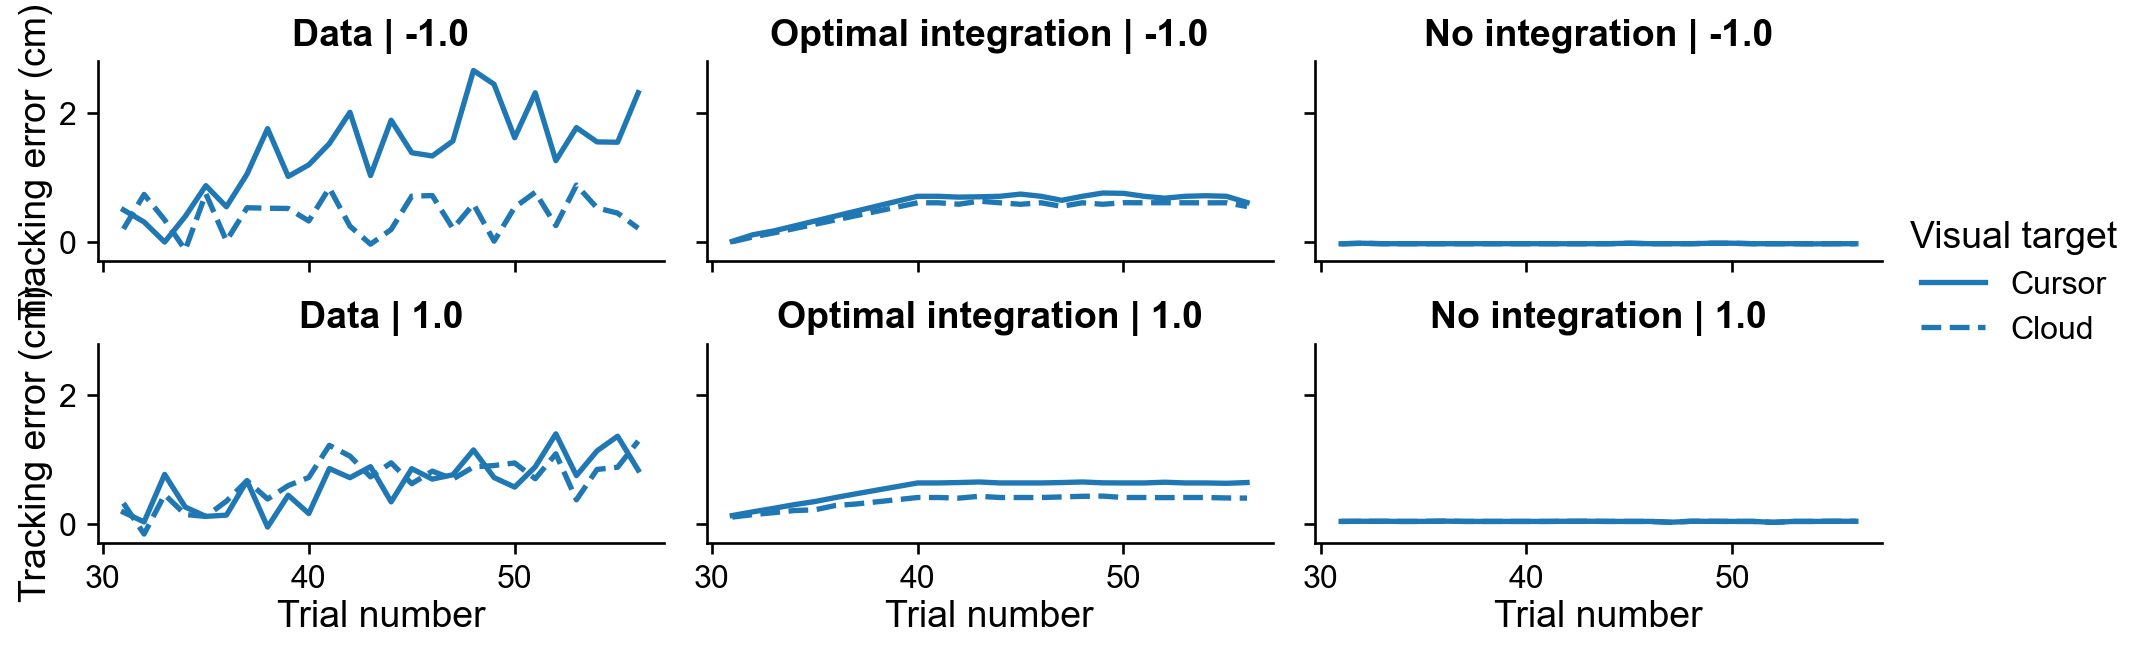

In [ ]:
#  "Optimal integration", "No integration"

mean_df = (
    df_sim[
        (df_sim["phase"].isin(["calibration"]))
        & (df_sim["model"].isin(["Data", "Optimal integration", "No integration"]))
    ]
    .groupby(["trial_number", "model", "Visual target", "participant"])[
        ["tracking_error", "abs_cursor_offset"]
    ]
    .mean()
    .reset_index()
)


g = (
    so.Plot(
        df_sim[
            (df_sim["phase"].isin(["calibration"]))
            & (df_sim["model"].isin(["Data", "Optimal integration", "No integration"]))
        ],
        # mean_df,
        x="trial_number",
        y="tracking_error",
        linestyle="Visual target",
    )
    .add(so.Line(), so.Agg())
    # .add(so.Line(color="gray"), so.Agg(), y="abs_cursor_offset", color=None)
    # .add(so.Band(), so.Est(errorbar="ci"))
    # .add(so.Line(alpha=0.5), so.Agg(), group="participant")
    .scale(linestyle=so.Nominal({"Cursor": "-", "Cloud": "--"}))
    .facet(col="model")
    .layout(size=(10, 3.5))
    .label(x="Trial number", y="Tracking error (cm)")
)
g.save("../figures/multisensory_calibration.svg", bbox_inches="tight")

In [37]:
df_wide = df_sim[df_sim["phase"] == "calibration"].pivot_table(index=["model", "participant", "trial_number"], columns="Visual target", values="tracking_error")
df_wide['diff'] = df_wide['Cursor'] - df_wide['Cloud']

df_wide = df_wide.reset_index()

df_wide = df_wide.groupby(["model", "participant", "trial_number"], as_index=False)["diff"].mean()

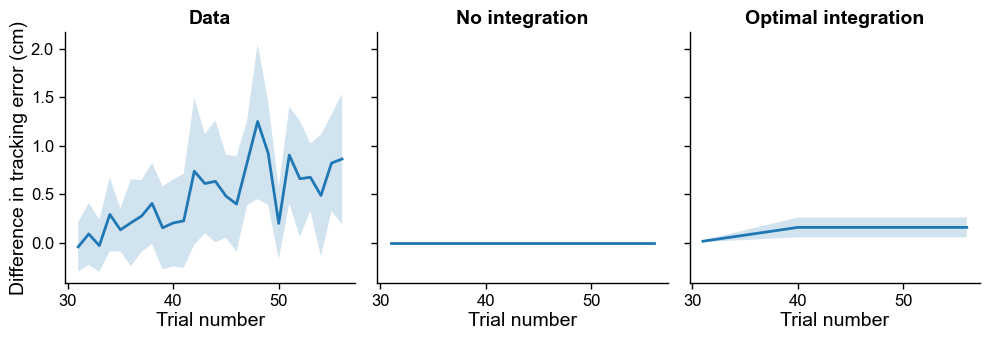

In [ ]:
g = (
    so.Plot(
        df_wide[df_wide["model"].isin(["Data", "Optimal integration", "No integration"])],
        x="trial_number",
        y="diff",
    )
    .add(so.Line(), so.Agg())
    # .add(so.Line(color="gray"), so.Agg(), y="abs_cursor_offset")
    .add(so.Band(), so.Est(errorbar="se"))
    .add(so.Line(color="gray"), so.Agg(), y=0)
    # .add(so.Line(alpha=0.5), so.Agg(), group="participant")
    .scale(color=so.Nominal())
    .facet(col="model")
    .layout(size=(10, 3.5))
    .label(x="Trial number", y="Difference in tracking error (cm)")
)
g.show()